In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("C:\\Users\\HP\\Desktop\\projects\\customer-churn-prediction\\data\\raw\\Telco_Cusomer_Churn.csv")

# Clean dataset
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Convert target
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

# Feature engineering
df["avg_monthly_spend"] = df["TotalCharges"] / (df["tenure"] + 1)

# Drop ID
df = df.drop("customerID", axis=1)

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Identify column types
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Model pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Train
pipeline.fit(X_train, y_train)

# Evaluate
pred = pipeline.predict(X_test)
prob = pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))

# Save model
joblib.dump(pipeline, "../model.pkl")

print("Model saved successfully")

Accuracy: 0.7619047619047619
ROC-AUC: 0.8301595477582038
Model saved successfully


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [4]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

results

{'Logistic Regression': 0.7960199004975125,
 'Random Forest': 0.7810945273631841,
 'XGBoost': 0.7647476901208244}

In [8]:
for model, score in results.items():
    print(f"{model}: {round(score*100,2)}%")

Logistic Regression: 79.6%
Random Forest: 78.11%
XGBoost: 76.47%


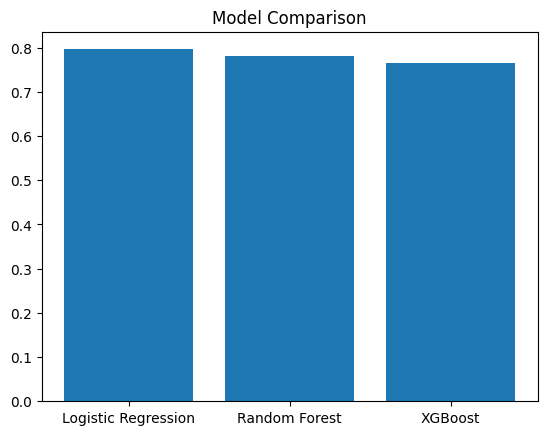

In [9]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.show()